In [1]:
!git clone https://github.com/eliftufekci/k_shortest_path_with_diversity.git

Cloning into 'k_shortest_path_with_diversity'...
remote: Enumerating objects: 449, done.
remote: Counting objects: 100% (285/285), done.
remote: Compressing objects: 100% (245/245), done.
remote: Total 449 (delta 182), reused 59 (delta 40), pack-reused 164 (from 1)
Receiving objects: 100% (449/449), 561.30 KiB | 20.05 MiB/s, done.
Resolving deltas: 100% (281/281), done.


In [4]:
import sys

top_level_container_dir = "k_shortest_path_with_diversity/"

if top_level_container_dir not in sys.path:
    sys.path.insert(0, top_level_container_dir)

In [5]:
import gc
import networkx as nx
import random
import datetime
import numpy as np

from k_shortest_path_with_diversity.examples import draw_bar_chart, download_and_prepare_graphs
from k_shortest_path_with_diversity.examples.draw_distribution import draw_time_distribution, draw_num_of_path_distribution
from k_shortest_path_with_diversity.src.algorithms import FindKSPD, FindKSPD_Yen, FindKSPD_Minus

In [6]:
def run_algorithm(algorithm, G, threshold, k, node_pairs):
    times = []
    num_paths = []

    for src, dest in node_pairs:
        print(f"\nComparing algorithms for SRC: {src}, DEST: {dest}")

        start_time = datetime.datetime.now()
        alg = algorithm(G, threshold)
        result = alg.find_paths(src=src, dest=dest, k=k)
        end_time = datetime.datetime.now()
        execution_time = end_time - start_time

        times.append(execution_time.total_seconds())
        num_paths.append(alg.number_of_paths_explored)


    return times, num_paths

In [7]:
def upload_graph(filepath, num_pairs):
    G = nx.DiGraph()
    with open(filepath) as f:
        for line in f:
            parts = line.split()
            if len(parts) == 3:  # Weighted graph (3 parçalı satır: kaynak, hedef, ağırlık)
                u, v, weight = int(parts[0]), int(parts[1]), float(parts[2])
                G.add_edge(u, v, weight=weight)
            elif len(parts) == 2:  # Unweighted graph (2 parçalı satır: kaynak ve hedef)
                u, v = map(int, parts)
                G.add_edge(u, v, weight=1)  # Ağırlıksız kenarları varsayılan olarak '1' ağırlıkla ekle
            else:
                raise ValueError("Unexpected line format in graph file.")

    node_pairs = []
    for _ in range(num_pairs):
        src = random.choice(list(G.nodes()))
        reachable = list(nx.descendants(G, src))

        while not reachable:
            src = random.choice(list(G.nodes()))
            reachable = list(nx.descendants(G, src))

        dest = random.choice(reachable)
        node_pairs.append((src, dest))

    return G, node_pairs

In [8]:
download_and_prepare_graphs()

k_to_find = 10
diversity_threshold = 0.6

Downloading: https://snap.stanford.edu/data/web-Google.txt.gz
Extracting: /content/graph-data/web-Google.txt.gz -> /content/graph-data/web-Google.txt
Removed archive: /content/graph-data/web-Google.txt.gz
Done: /content/graph-data/web-Google.txt
Downloading: https://snap.stanford.edu/data/wiki-Talk.txt.gz
Extracting: /content/graph-data/wiki-Talk.txt.gz -> /content/graph-data/wiki-Talk.txt
Removed archive: /content/graph-data/wiki-Talk.txt.gz
Done: /content/graph-data/wiki-Talk.txt
Downloading: https://www.diag.uniroma1.it/challenge9/data/USA-road-d/USA-road-d.FLA.gr.gz
Extracting: /content/graph-data/USA-road-d.FLA.gr.gz -> /content/graph-data/USA-road-d.FLA.gr
Removed archive: /content/graph-data/USA-road-d.FLA.gr.gz
Done: /content/graph-data/USA-road-d.FLA.gr
Downloading: https://www.diag.uniroma1.it/challenge9/data/USA-road-d/USA-road-d.COL.gr.gz
Extracting: /content/graph-data/USA-road-d.COL.gr.gz -> /content/graph-data/USA-road-d.COL.gr
Removed archive: /content/graph-data/USA-ro

In [9]:
web_google_path = "/content/graph-data/web-Google.txt"
num_pairs = 10
G, node_pairs = upload_graph(web_google_path, num_pairs)

print(node_pairs)

[(317295, 423011), (439293, 819877), (489596, 774069), (718999, 473585), (367169, 653810), (776718, 336305), (816273, 489579), (837899, 292745), (605030, 477725), (370375, 881846)]


In [11]:
print("working with KSPD")
kspd_times, kspd_num_paths = run_algorithm(FindKSPD, G, diversity_threshold, k_to_find, node_pairs)

kspd_avg_time = np.average(kspd_times) if kspd_times else 0
kspd_avg_num_paths = np.average(kspd_num_paths) if kspd_num_paths else 0

print(f"kspd_times: {kspd_times}")
print(f"kspd_num_paths: {kspd_num_paths}")
print(f"kspd_avg_time: {kspd_avg_time}")
print(f"kspd_avg_num_paths: {kspd_avg_num_paths}")

working with KSPD

Comparing algorithms for SRC: 317295, DEST: 423011

Comparing algorithms for SRC: 439293, DEST: 819877

Comparing algorithms for SRC: 489596, DEST: 774069

Comparing algorithms for SRC: 718999, DEST: 473585

Comparing algorithms for SRC: 367169, DEST: 653810

Comparing algorithms for SRC: 776718, DEST: 336305

Comparing algorithms for SRC: 816273, DEST: 489579

Comparing algorithms for SRC: 837899, DEST: 292745

Comparing algorithms for SRC: 605030, DEST: 477725

Comparing algorithms for SRC: 370375, DEST: 881846
kspd_times: [37.467401, 39.109449, 33.488182, 49.839733, 64.556972, 44.295465, 51.331978, 48.079303, 20.790867, 58.876938]
kspd_num_paths: [57, 120, 1, 52, 300, 20, 108, 91, 9, 13]
kspd_avg_time: 44.7836288
kspd_avg_num_paths: 77.1


In [12]:
print("working with KSPD_Minus")
kspd_minus_times, kspd_minus_num_paths = run_algorithm(FindKSPD_Minus, G, diversity_threshold, k_to_find, node_pairs)

kspd_minus_avg_time = np.average(kspd_minus_times) if kspd_minus_times else 0
kspd_minus_avg_num_paths = np.average(kspd_minus_num_paths) if kspd_minus_num_paths else 0

print(f"kspd_minus_times: {kspd_minus_times}")
print(f"kspd_minus_num_paths: {kspd_minus_num_paths}")
print(f"kspd_minus_avg_time: {kspd_minus_avg_time}")
print(f"kspd_minus_avg_num_paths: {kspd_minus_avg_num_paths}")

working with KSPD_Minus

Comparing algorithms for SRC: 317295, DEST: 423011

Comparing algorithms for SRC: 439293, DEST: 819877

Comparing algorithms for SRC: 489596, DEST: 774069

Comparing algorithms for SRC: 718999, DEST: 473585

Comparing algorithms for SRC: 367169, DEST: 653810

Comparing algorithms for SRC: 776718, DEST: 336305

Comparing algorithms for SRC: 816273, DEST: 489579

Comparing algorithms for SRC: 837899, DEST: 292745

Comparing algorithms for SRC: 605030, DEST: 477725

Comparing algorithms for SRC: 370375, DEST: 881846
kspd_minus_times: [45.73204, 38.836919, 30.027647, 46.69441, 62.745876, 48.511545, 54.763948, 49.479465, 21.722915, 58.890513]
kspd_minus_num_paths: [195, 130, 1, 58, 240, 18, 84, 90, 9, 24]
kspd_minus_avg_time: 45.7405278
kspd_minus_avg_num_paths: 84.9


In [13]:
# print("working with KSPD_Yen")
# kspd_yen_times, kspd_yen_num_paths = run_algorithm(FindKSPD_Yen, G, diversity_threshold, k_to_find, node_pairs)

# kspd_yen_avg_time = np.average(kspd_yen_times) if kspd_yen_times else 0
# kspd_yen_avg_num_paths = np.average(kspd_yen_num_paths) if kspd_yen_num_paths else 0

kspd_yen_times = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted
kspd_yen_num_paths = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted

kspd_yen_avg_time = 10**6
kspd_yen_avg_num_paths =  10**6

In [17]:
web_google_result = ((kspd_avg_time, kspd_avg_num_paths, kspd_times, kspd_num_paths),
                     (kspd_minus_avg_time, kspd_minus_avg_num_paths, kspd_minus_times, kspd_minus_num_paths),
                     (kspd_yen_avg_time, kspd_yen_avg_num_paths, kspd_yen_times, kspd_yen_num_paths))

print(web_google_result)

((np.float64(44.7836288), np.float64(77.1), [37.467401, 39.109449, 33.488182, 49.839733, 64.556972, 44.295465, 51.331978, 48.079303, 20.790867, 58.876938], [57, 120, 1, 52, 300, 20, 108, 91, 9, 13]), (np.float64(45.7405278), np.float64(84.9), [45.73204, 38.836919, 30.027647, 46.69441, 62.745876, 48.511545, 54.763948, 49.479465, 21.722915, 58.890513], [195, 130, 1, 58, 240, 18, 84, 90, 9, 24]), (1000000, 1000000, array([inf, inf, inf, inf, inf, inf, inf, inf, inf, inf]), array([inf, inf, inf, inf, inf, inf, inf, inf, inf, inf])))


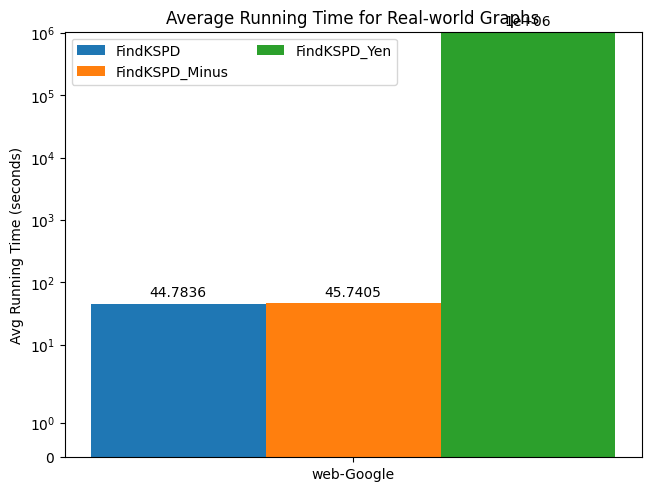

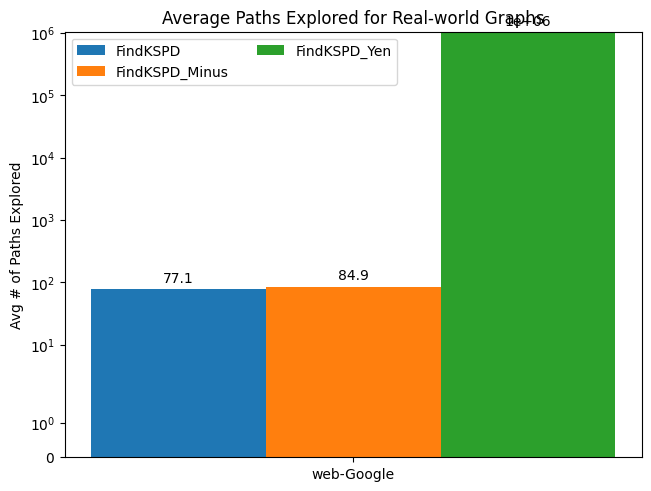

In [18]:
graph_types = ("web-Google",)

algorithms_time = {
    'FindKSPD':       [web_google_result[0][0]],  # index 0 = avg_time
    'FindKSPD_Minus': [web_google_result[1][0]],
    'FindKSPD_Yen':   [web_google_result[2][0]],
}

algorithms_paths = {
    'FindKSPD':       [web_google_result[0][1]],  # index 1 = avg_num_paths
    'FindKSPD_Minus': [web_google_result[1][1]],
    'FindKSPD_Yen':   [web_google_result[2][1]],
}

draw_bar_chart(graph_types, algorithms_paths, algorithms_time)

In [19]:
del G
gc.collect()

11575

In [16]:
wiki_talk_path  = "/content/graph-data/wiki-Talk.txt"
num_pairs = 10
G, node_pairs = upload_graph(wiki_talk_path, num_pairs)
print(node_pairs)

In [ ]:
print("working with KSPD")
kspd_times, kspd_num_paths = run_algorithm(FindKSPD, G, diversity_threshold, k_to_find, node_pairs)

kspd_avg_time = np.average(kspd_times) if kspd_times else 0
kspd_avg_num_paths = np.average(kspd_num_paths) if kspd_num_paths else 0

print(f"kspd_times: {kspd_times}")
print(f"kspd_num_paths: {kspd_num_paths}")
print(f"kspd_avg_time: {kspd_avg_time}")
print(f"kspd_avg_num_paths: {kspd_avg_num_paths}")

In [ ]:
print("working with KSPD_Minus")
kspd_minus_times, kspd_minus_num_paths = run_algorithm(FindKSPD_Minus, G, diversity_threshold, k_to_find, node_pairs)

kspd_minus_avg_time = np.average(kspd_minus_times) if kspd_minus_times else 0
kspd_minus_avg_num_paths = np.average(kspd_minus_num_paths) if kspd_minus_num_paths else 0

print(f"kspd_minus_times: {kspd_minus_times}")
print(f"kspd_minus_num_paths: {kspd_minus_num_paths}")
print(f"kspd_minus_avg_time: {kspd_minus_avg_time}")
print(f"kspd_minus_avg_num_paths: {kspd_minus_avg_num_paths}")

In [ ]:
# print("working with KSPD_Yen")
# kspd_yen_times, kspd_yen_num_paths = run_algorithm(FindKSPD_Yen, G, diversity_threshold, k_to_find, node_pairs)

# kspd_yen_avg_time = np.average(kspd_yen_times) if kspd_yen_times else 0
# kspd_yen_avg_num_paths = np.average(kspd_yen_num_paths) if kspd_yen_num_paths else 0

kspd_yen_times = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted
kspd_yen_num_paths = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted

kspd_yen_avg_time = 10**6
kspd_yen_avg_num_paths =  10**6

In [ ]:
wiki_talk_result = ((kspd_avg_time, kspd_avg_num_paths, kspd_times, kspd_num_paths),
                     (kspd_minus_avg_time, kspd_minus_avg_num_paths, kspd_minus_times, kspd_minus_num_paths),
                     (kspd_yen_avg_time, kspd_yen_avg_num_paths, kspd_yen_times, kspd_yen_num_paths))

print(wiki_talk_result)

In [ ]:
all_results = [web_google_result, wiki_talk_result]

graph_types = ("web-Google", "wiki-Talk")

algorithms_time = {
    'FindKSPD':       [r[0][0] for r in all_results],  # index 0 = avg_time
    'FindKSPD_Minus': [r[1][0] for r in all_results],
    'FindKSPD_Yen':   [r[2][0] for r in all_results],
}

algorithms_paths = {
    'FindKSPD':       [r[0][1] for r in all_results],  # index 1 = avg_num_paths
    'FindKSPD_Minus': [r[1][1] for r in all_results],
    'FindKSPD_Yen':   [r[2][1] for r in all_results],
}
draw_bar_chart(graph_types, algorithms_paths, algorithms_time)

In [ ]:
del G
gc.collect()

In [ ]:
roadCOL_path    = "/content/graph-data/USA-road-d.COL.gr"
num_pairs = 1
G, node_pairs = upload_graph(roadCOL_path, num_pairs)
print(node_pairs)

In [ ]:
print("working with KSPD")
kspd_times, kspd_num_paths = run_algorithm(FindKSPD, G, diversity_threshold, k_to_find, node_pairs)

kspd_avg_time = np.average(kspd_times) if kspd_times else 0
kspd_avg_num_paths = np.average(kspd_num_paths) if kspd_num_paths else 0

print(f"kspd_times: {kspd_times}")
print(f"kspd_num_paths: {kspd_num_paths}")
print(f"kspd_avg_time: {kspd_avg_time}")
print(f"kspd_avg_num_paths: {kspd_avg_num_paths})

In [ ]:
print("working with KSPD_Minus")
kspd_minus_times, kspd_minus_num_paths = run_algorithm(FindKSPD_Minus, G, diversity_threshold, k_to_find, node_pairs)

kspd_minus_avg_time = np.average(kspd_minus_times) if kspd_minus_times else 0
kspd_minus_avg_num_paths = np.average(kspd_minus_num_paths) if kspd_minus_num_paths else 0

print(f"kspd_minus_times: {kspd_minus_times}")
print(f"kspd_minus_num_paths: {kspd_minus_num_paths}")
print(f"kspd_minus_avg_time: {kspd_minus_avg_time}")
print(f"kspd_minus_avg_num_paths: {kspd_minus_avg_num_paths}")

In [ ]:
# print("working with KSPD_Yen")
# kspd_yen_times, kspd_yen_num_paths = run_algorithm(FindKSPD_Yen, G, diversity_threshold, k_to_find, node_pairs)

# kspd_yen_avg_time = np.average(kspd_yen_times) if kspd_yen_times else 0
# kspd_yen_avg_num_paths = np.average(kspd_yen_num_paths) if kspd_yen_num_paths else 0

kspd_yen_times = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted
kspd_yen_num_paths = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted

kspd_yen_avg_time = 10**6
kspd_yen_avg_num_paths =  10**6

In [ ]:
roadCOL_result = ((kspd_avg_time, kspd_avg_num_paths, kspd_times, kspd_num_paths),
                     (kspd_minus_avg_time, kspd_minus_avg_num_paths, kspd_minus_times, kspd_minus_num_paths),
                     (kspd_yen_avg_time, kspd_yen_avg_num_paths, kspd_yen_times, kspd_yen_num_paths))

print(roadCOL_result)

In [ ]:
all_results = [web_google_result, wiki_talk_result, roadCOL_result]

graph_types = ("web-Google", "wiki-Talk", "RoadCOL")

algorithms_time = {
    'FindKSPD':       [r[0][0] for r in all_results],  # index 0 = avg_time
    'FindKSPD_Minus': [r[1][0] for r in all_results],
    'FindKSPD_Yen':   [r[2][0] for r in all_results],
}

algorithms_paths = {
    'FindKSPD':       [r[0][1] for r in all_results],  # index 1 = avg_num_paths
    'FindKSPD_Minus': [r[1][1] for r in all_results],
    'FindKSPD_Yen':   [r[2][1] for r in all_results],
}
draw_bar_chart(graph_types, algorithms_paths, algorithms_time)

In [ ]:
del G
gc.collect()

In [ ]:
roadFLA_path = "/content/graph-data/USA-road-d.FLA.gr"
num_pairs = 1
G, node_pairs = upload_graph(roadFLA_path, num_pairs)
print(node_pairs)

In [ ]:
print("working with KSPD")
kspd_times, kspd_num_paths = run_algorithm(FindKSPD, G, diversity_threshold, k_to_find, node_pairs)

kspd_avg_time = np.average(kspd_times) if kspd_times else 0
kspd_avg_num_paths = np.average(kspd_num_paths) if kspd_num_paths else 0

print(f"kspd_times: {kspd_times}")
print(f"kspd_num_paths: {kspd_num_paths}")
print(f"kspd_avg_time: {kspd_avg_time}")
print(f"kspd_avg_num_paths: {kspd_avg_num_paths}")

In [ ]:
print("working with KSPD_Minus")
kspd_minus_times, kspd_minus_num_paths = run_algorithm(FindKSPD_Minus, G, diversity_threshold, k_to_find, node_pairs)

kspd_minus_avg_time = np.average(kspd_minus_times) if kspd_minus_times else 0
kspd_minus_avg_num_paths = np.average(kspd_minus_num_paths) if kspd_minus_num_paths else 0

print(f"kspd_minus_times: {kspd_minus_times}")
print(f"kspd_minus_num_paths: {kspd_minus_num_paths}")
print(f"kspd_minus_avg_time: {kspd_minus_avg_time}")
print(f"kspd_minus_avg_num_paths: {kspd_minus_avg_num_paths}")

In [ ]:
# print("working with KSPD_Yen")
# kspd_yen_times, kspd_yen_num_paths = run_algorithm(FindKSPD_Yen, G, diversity_threshold, k_to_find, node_pairs)

# kspd_yen_avg_time = np.average(kspd_yen_times) if kspd_yen_times else 0
# kspd_yen_avg_num_paths = np.average(kspd_yen_num_paths) if kspd_yen_num_paths else 0

kspd_yen_times = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted
kspd_yen_num_paths = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted

kspd_yen_avg_time = 10**6
kspd_yen_avg_num_paths =  10**6

In [ ]:
roadFLA_result = ((kspd_avg_time, kspd_avg_num_paths, kspd_times, kspd_num_paths),
                     (kspd_minus_avg_time, kspd_minus_avg_num_paths, kspd_minus_times, kspd_minus_num_paths),
                     (kspd_yen_avg_time, kspd_yen_avg_num_paths, kspd_yen_times, kspd_yen_num_paths))

print(roadFLA_result)

In [ ]:
all_results = [web_google_result, wiki_talk_result, roadCOL_result, roadFLA_result]

graph_types = ("web-Google", "wiki-Talk", "RoadCOL", "RoadFLA")

algorithms_time = {
    'FindKSPD':       [r[0][0] for r in all_results],  # index 0 = avg_time
    'FindKSPD_Minus': [r[1][0] for r in all_results],
    'FindKSPD_Yen':   [r[2][0] for r in all_results],
}

algorithms_paths = {
    'FindKSPD':       [r[0][1] for r in all_results],  # index 1 = avg_num_paths
    'FindKSPD_Minus': [r[1][1] for r in all_results],
    'FindKSPD_Yen':   [r[2][1] for r in all_results],
}

draw_bar_chart(graph_types, algorithms_paths, algorithms_time)